分類結果
              precision    recall  f1-score   support

           0       0.56      0.71      0.63        52
           1       0.50      0.34      0.41        44

    accuracy                           0.54        96
   macro avg       0.53      0.53      0.52        96
weighted avg       0.53      0.54      0.53        96


SHAP重要度
         feature  mean_abs_shap
2           ma25       0.444037
6    return_lag3       0.290942
5    return_lag2       0.260451
4    return_lag1       0.224576
8   return_lag10       0.209364
7    return_lag5       0.184039
9     price_lag1       0.159868
0         return       0.134164
3    volatility5       0.105637
1            ma5       0.101462
13   price_lag10       0.089071
12    price_lag5       0.067944
11    price_lag3       0.052631
10    price_lag2       0.039064


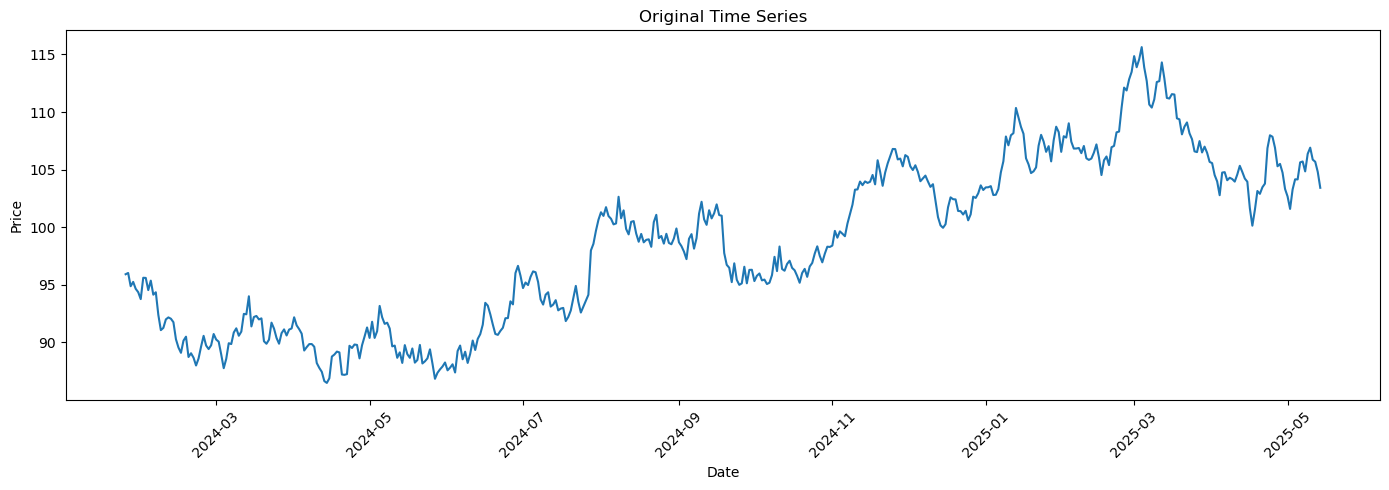

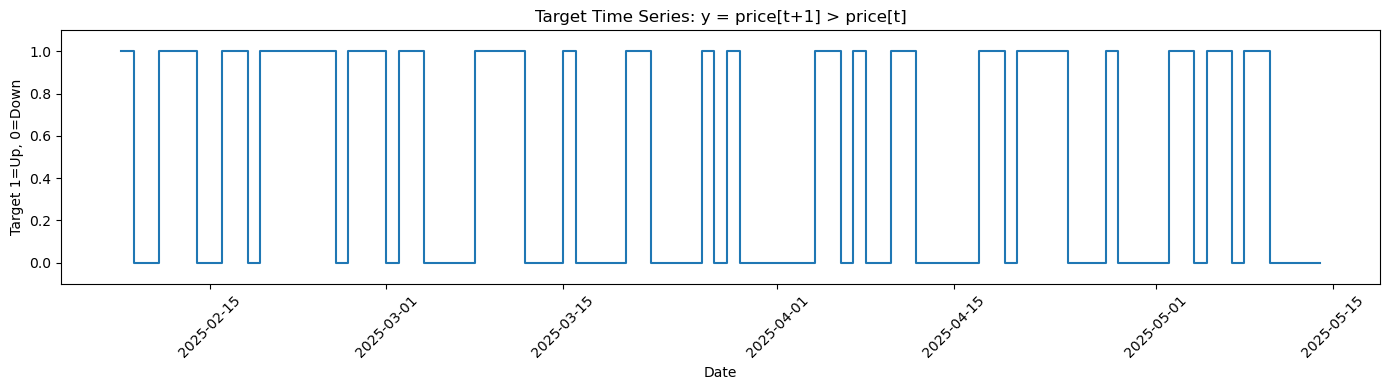

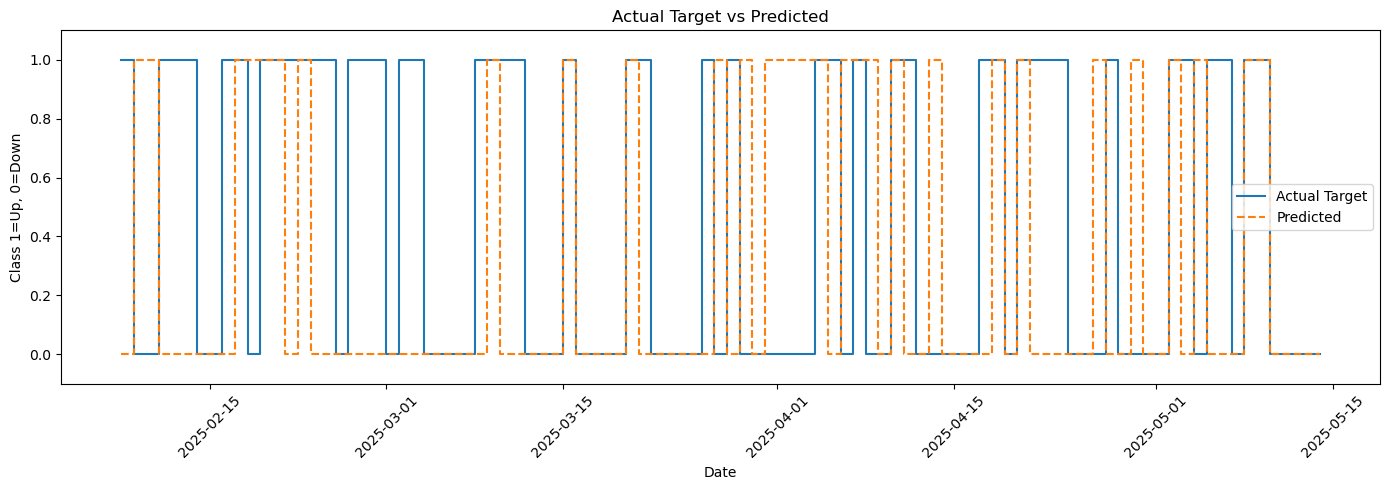

C:\Users\user\AppData\Local\Temp\ipykernel_4564\3269862538.py:258: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


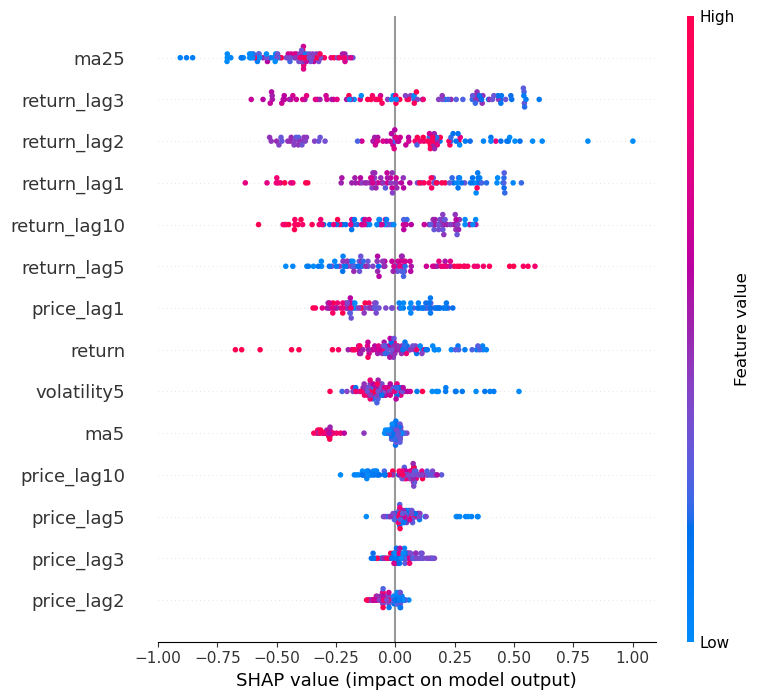

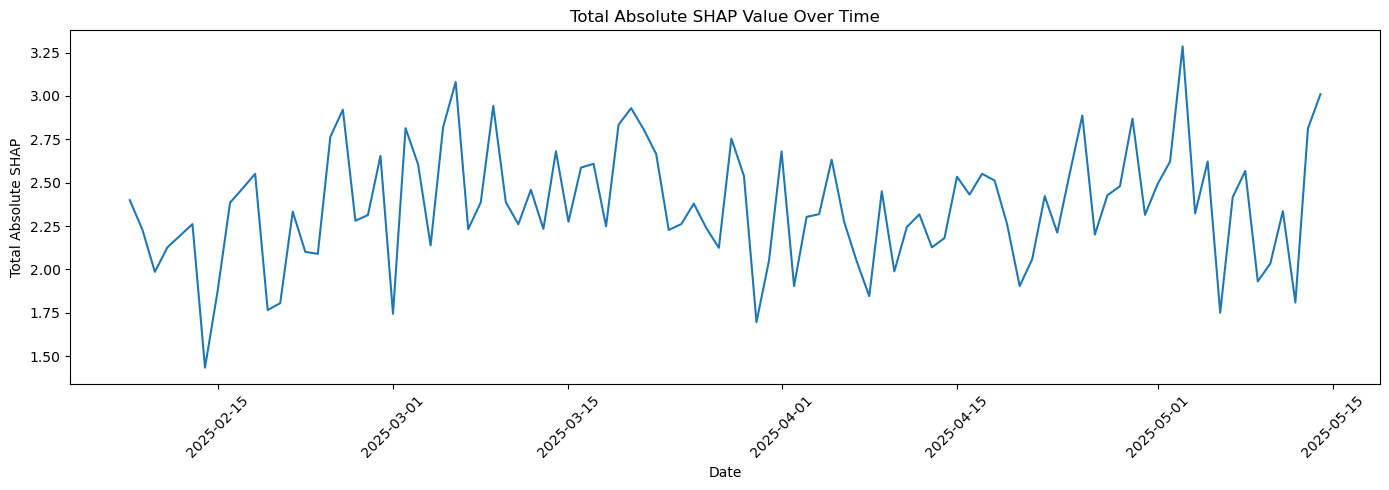

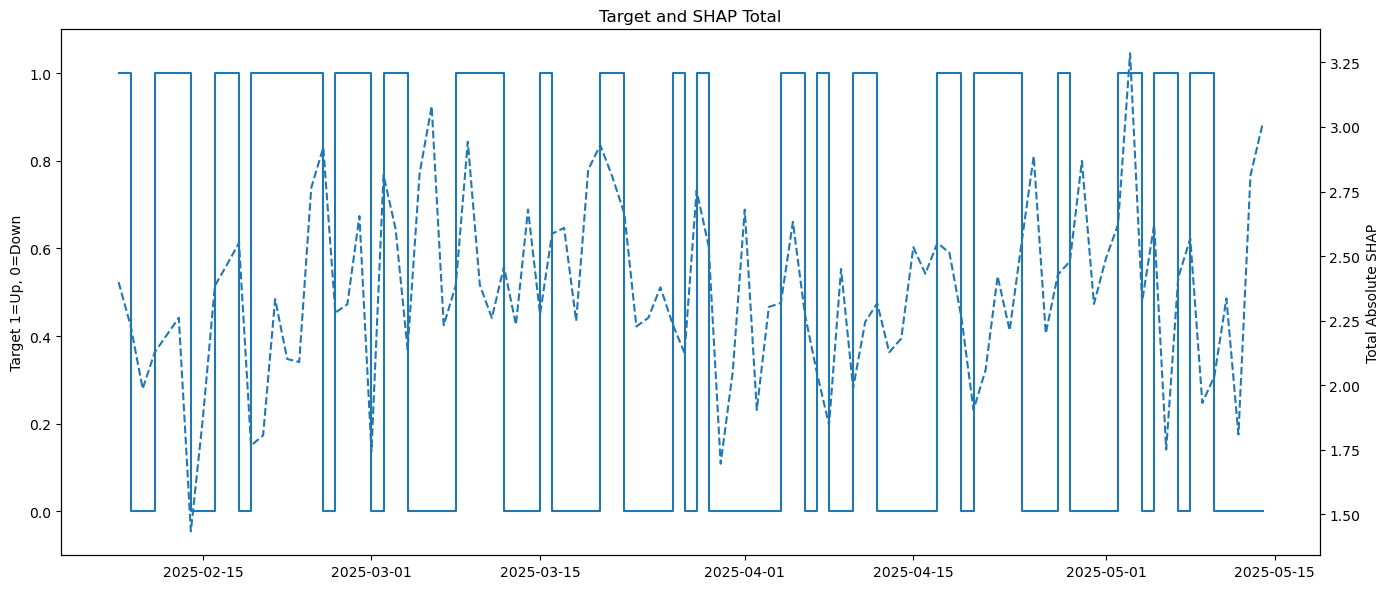

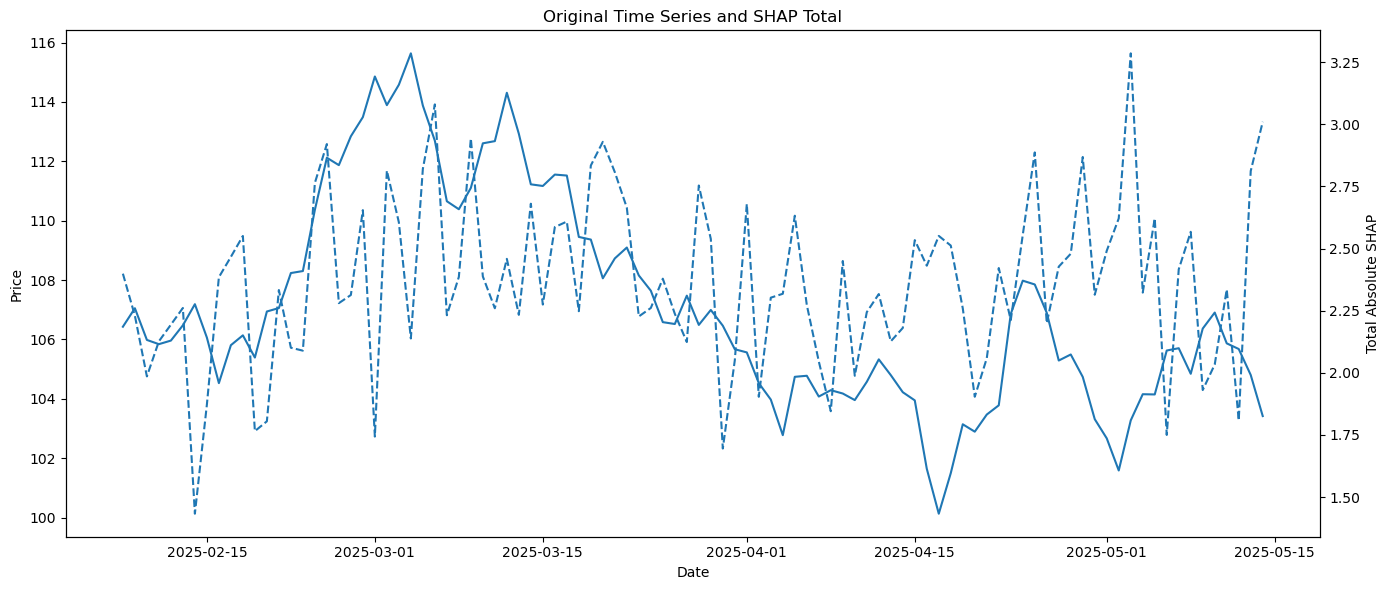

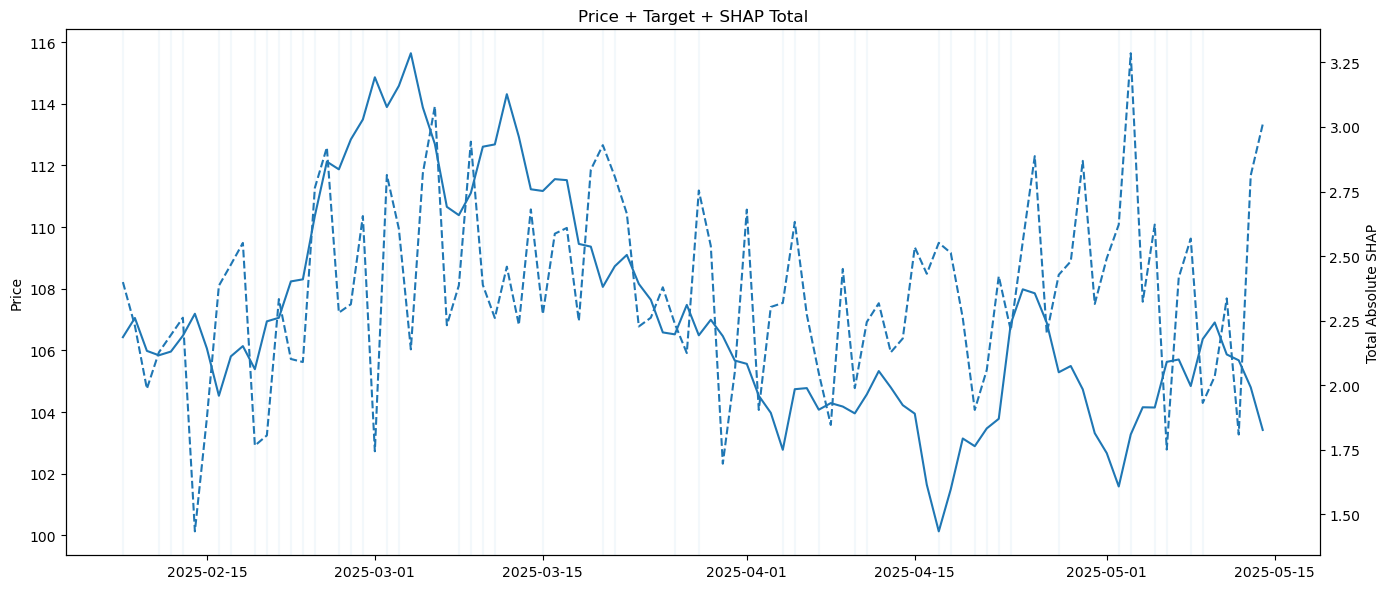

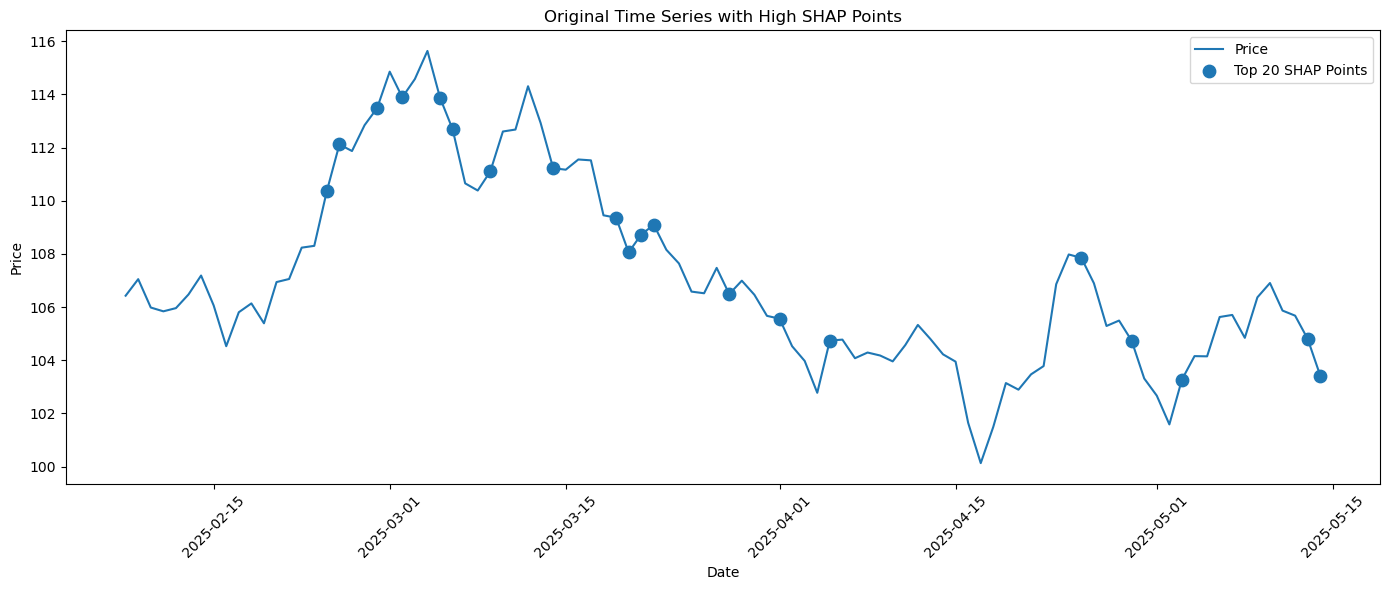


SHAP説明品質指標
                          metric         value
0                 model_accuracy  5.416667e-01
1                model_precision  5.000000e-01
2                   model_recall  3.409091e-01
3                       model_f1  4.054054e-01
4                   fidelity_mae  1.931136e-07
5                  fidelity_rmse  2.761821e-07
6                  fidelity_corr  1.000000e+00
7              shap_entropy_mean  2.206015e+00
8   shap_entropy_normalized_mean  8.359103e-01
9        shap_concentration_mean  1.640897e-01
10          shap_top1_ratio_mean  2.296342e-01
11          shap_top3_ratio_mean  5.375862e-01
12         stability_cosine_mean  9.927499e-01
13          stability_cosine_std  2.461049e-02


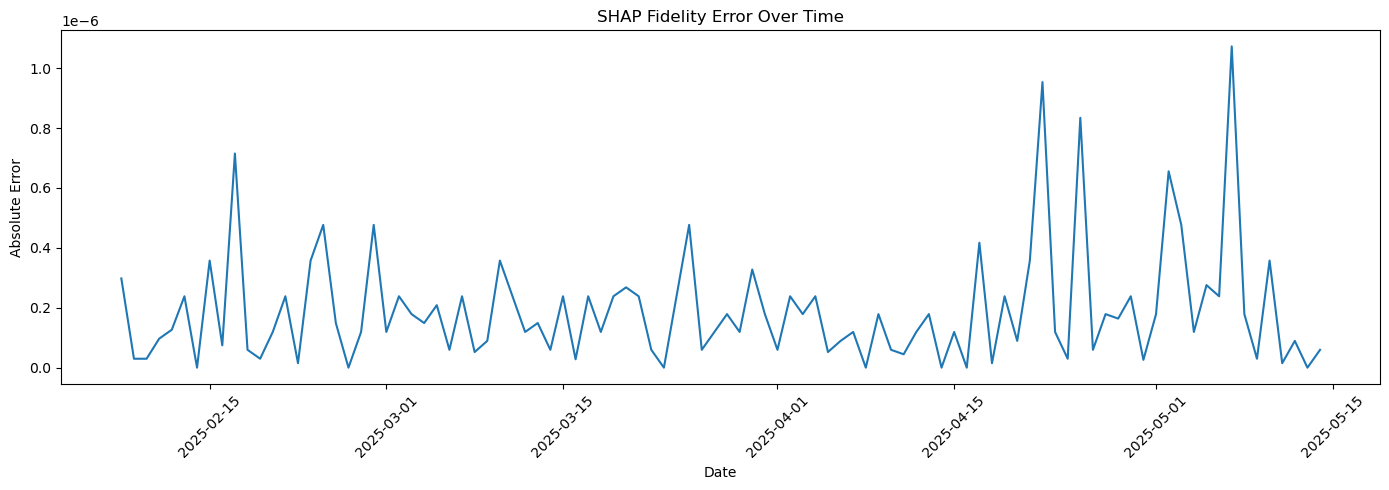

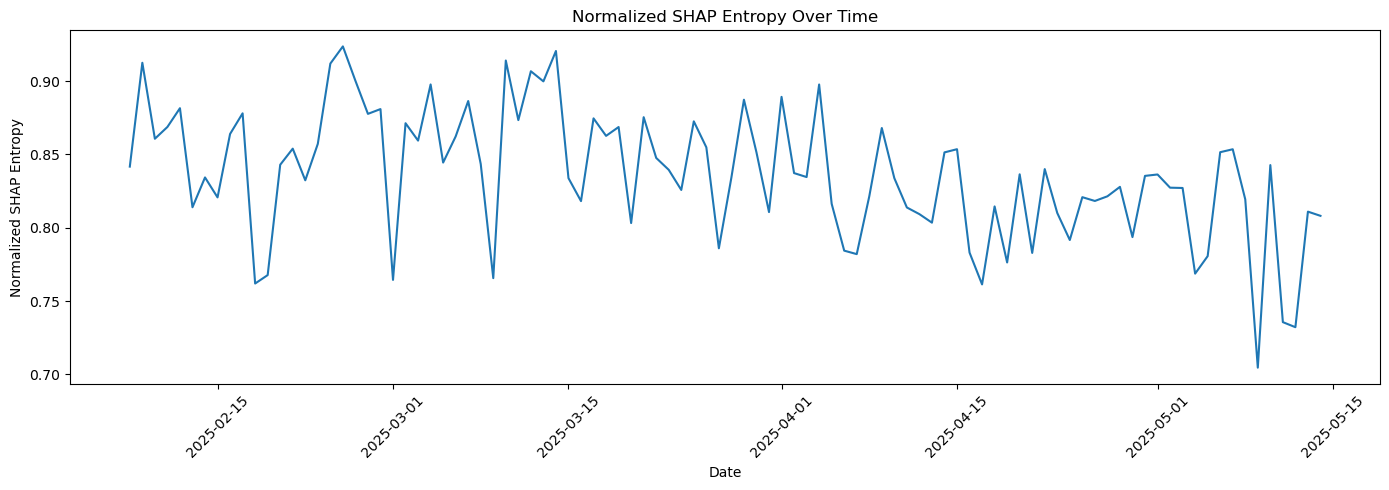

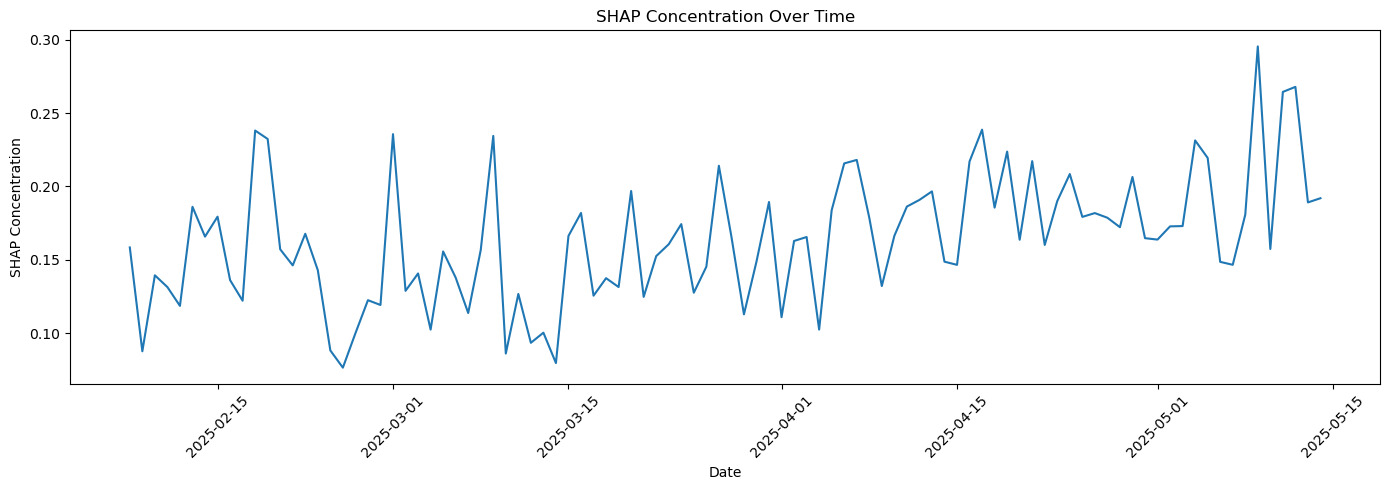

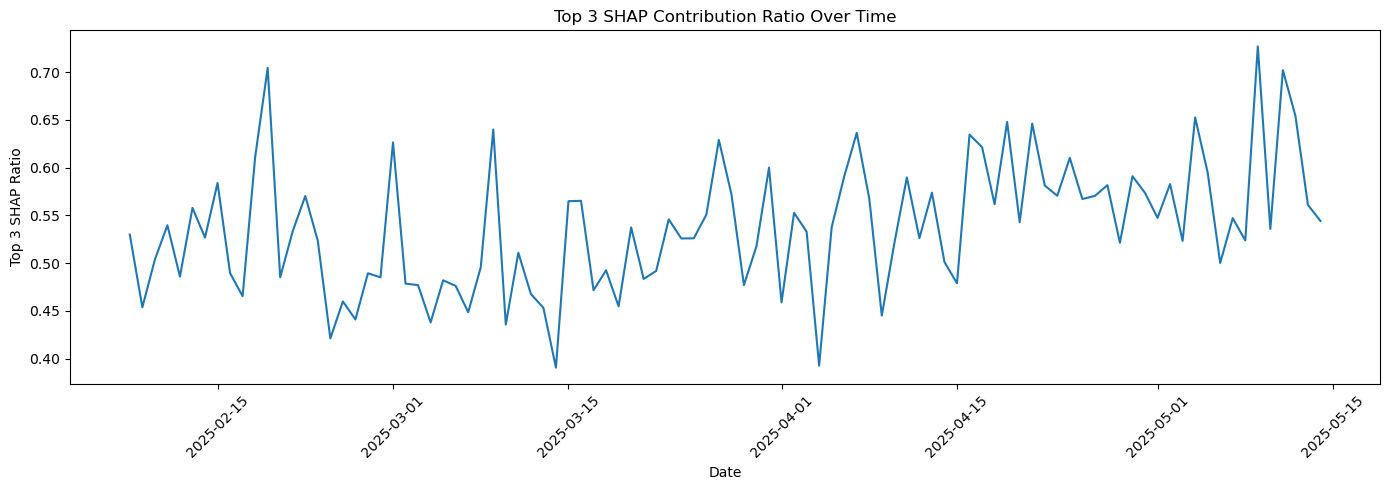

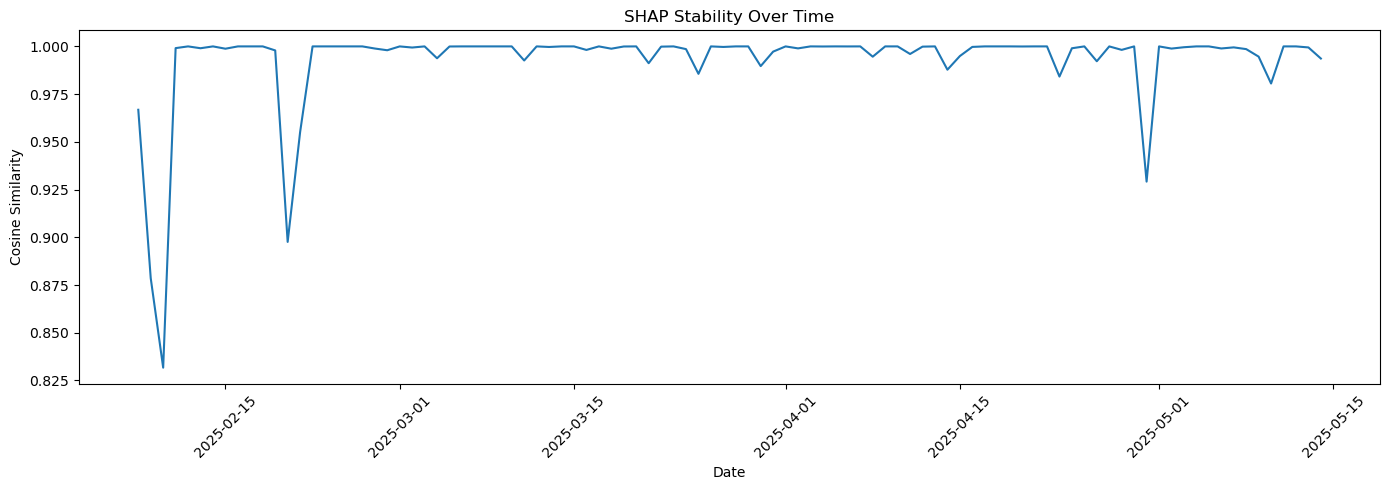


保存したフォルダ
timeseries_shap_outputs

主な保存ファイル
original_timeseries.png
target_timeseries.png
actual_vs_predicted.png
shap_summary_plot.png
shap_total_abs_over_time.png
target_vs_shap_total.png
price_vs_shap_total.png
price_target_shap_combined.png
original_timeseries_with_high_shap_points.png

CSV
timeseries_shap_feature_importance.csv
timeseries_shap_by_date.csv
top_shap_points.csv
shap_target_feature_timeseries.csv
shap_values_by_feature.csv
feature_timeseries_and_shap_values.csv
shap_fidelity_entropy_stability_by_date.csv
shap_fidelity_entropy_stability_summary.csv

SHAP説明品質プロット
shap_fidelity_error_over_time.png
shap_entropy_over_time.png
shap_concentration_over_time.png
shap_top3_ratio_over_time.png
shap_stability_over_time.png

各特徴量について保存される画像
feature_timeseries_<feature>.png
shap_timeseries_<feature>.png
feature_and_shap_timeseries_<feature>.png
feature_value_vs_shap_<feature>.png


In [1]:
# pip install pandas numpy matplotlib scikit-learn xgboost shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)

from sklearn.metrics.pairwise import cosine_similarity

from xgboost import XGBClassifier
import shap


# =====================================================
# 0. 設定
# =====================================================

OUTPUT_DIR = Path("timeseries_shap_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

np.random.seed(42)

STABILITY_NOISE_LEVEL = 0.01


# =====================================================
# 1. サンプル時系列データ作成
# =====================================================

n = 500
date = pd.date_range("2024-01-01", periods=n, freq="D")

price = 100 + np.cumsum(
    np.random.normal(0, 1, n)
)

df = pd.DataFrame({
    "date": date,
    "price": price
})


# =====================================================
# 2. 基本特徴量
# =====================================================

df["return"] = df["price"].pct_change()
df["ma5"] = df["price"].rolling(5).mean()
df["ma25"] = df["price"].rolling(25).mean()
df["volatility5"] = df["return"].rolling(5).std()


# =====================================================
# 3. ラグ特徴量
# =====================================================

for lag in [1, 2, 3, 5, 10]:
    df[f"return_lag{lag}"] = df["return"].shift(lag)
    df[f"price_lag{lag}"] = df["price"].shift(lag)


# =====================================================
# 4. 目的変数
#    y = price[t+1] > price[t]
# =====================================================

df["target"] = (
    df["price"].shift(-1) > df["price"]
).astype(int)

df = df.dropna().reset_index(drop=True)


# =====================================================
# 5. 説明変数
# =====================================================

feature_cols = [
    "return",
    "ma5",
    "ma25",
    "volatility5",
    "return_lag1",
    "return_lag2",
    "return_lag3",
    "return_lag5",
    "return_lag10",
    "price_lag1",
    "price_lag2",
    "price_lag3",
    "price_lag5",
    "price_lag10",
]

X = df[feature_cols]
y = df["target"]


# =====================================================
# 6. 時系列分割
# =====================================================

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

date_test = df["date"].iloc[split:].reset_index(drop=True)
price_test = df["price"].iloc[split:].reset_index(drop=True)
target_test = y_test.reset_index(drop=True)


# =====================================================
# 7. モデル学習
# =====================================================

model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
pred_series = pd.Series(pred)

print("分類結果")
print(classification_report(y_test, pred))


# =====================================================
# 8. SHAP値計算
# =====================================================

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_values = np.asarray(shap_values)


# =====================================================
# 9. SHAP重要度
# =====================================================

shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print("\nSHAP重要度")
print(shap_importance)

shap_importance.to_csv(
    OUTPUT_DIR / "timeseries_shap_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 10. 元データをプロット
# =====================================================

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["price"])
plt.title("Original Time Series")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "original_timeseries.png", dpi=150)
plt.show()


# =====================================================
# 11. target時系列をプロット
# =====================================================

plt.figure(figsize=(14, 4))

plt.plot(
    date_test,
    target_test,
    drawstyle="steps-post"
)

plt.ylim(-0.1, 1.1)
plt.title("Target Time Series: y = price[t+1] > price[t]")
plt.xlabel("Date")
plt.ylabel("Target 1=Up, 0=Down")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "target_timeseries.png", dpi=150)
plt.show()


# =====================================================
# 12. target と prediction の比較
# =====================================================

plt.figure(figsize=(14, 5))

plt.plot(
    date_test,
    target_test,
    drawstyle="steps-post",
    label="Actual Target"
)

plt.plot(
    date_test,
    pred_series,
    drawstyle="steps-post",
    linestyle="--",
    label="Predicted"
)

plt.ylim(-0.1, 1.1)
plt.title("Actual Target vs Predicted")
plt.xlabel("Date")
plt.ylabel("Class 1=Up, 0=Down")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "actual_vs_predicted.png", dpi=150)
plt.show()


# =====================================================
# 13. SHAP summary plot
# =====================================================

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary_plot.png", dpi=150)
plt.show()


# =====================================================
# 14. SHAP対象の特徴量時系列をすべてプロット
# =====================================================

for feature in feature_cols:
    plt.figure(figsize=(14, 5))

    plt.plot(
        date_test,
        X_test[feature].reset_index(drop=True)
    )

    plt.title(f"Feature Time Series: {feature}")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"feature_timeseries_{feature}.png",
        dpi=150
    )
    plt.close()


# =====================================================
# 15. 特徴量ごとのSHAP時系列プロット
# =====================================================

for feature in feature_cols:
    feature_index = list(X_test.columns).index(feature)

    plt.figure(figsize=(14, 5))

    plt.plot(
        date_test,
        shap_values[:, feature_index]
    )

    plt.axhline(0, linestyle="--")
    plt.title(f"SHAP Value Over Time: {feature}")
    plt.xlabel("Date")
    plt.ylabel("SHAP Value")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"shap_timeseries_{feature}.png",
        dpi=150
    )
    plt.close()


# =====================================================
# 16. 特徴量時系列 + SHAP時系列
# =====================================================

for feature in feature_cols:
    feature_index = list(X_test.columns).index(feature)
    feature_series = X_test[feature].reset_index(drop=True)

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(14, 8),
        sharex=True
    )

    ax1.plot(date_test, feature_series)
    ax1.set_title(f"Feature Time Series: {feature}")
    ax1.set_ylabel(feature)

    ax2.plot(date_test, shap_values[:, feature_index])
    ax2.axhline(0, linestyle="--")
    ax2.set_title(f"SHAP Value Over Time: {feature}")
    ax2.set_xlabel("Date")
    ax2.set_ylabel("SHAP Value")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"feature_and_shap_timeseries_{feature}.png",
        dpi=150
    )
    plt.close()


# =====================================================
# 17. 特徴量の値 vs SHAP値
# =====================================================

for feature in feature_cols:
    feature_index = list(X_test.columns).index(feature)

    plt.figure(figsize=(7, 5))

    plt.scatter(
        X_test[feature],
        shap_values[:, feature_index],
        alpha=0.7
    )

    plt.axhline(0, linestyle="--")
    plt.title(f"Feature Value vs SHAP Value: {feature}")
    plt.xlabel(feature)
    plt.ylabel("SHAP Value")
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"feature_value_vs_shap_{feature}.png",
        dpi=150
    )
    plt.close()


# =====================================================
# 18. 各時点のSHAP総量
# =====================================================

shap_total_abs = np.abs(shap_values).sum(axis=1)

df_shap_time = pd.DataFrame({
    "date": date_test,
    "price": price_test,
    "target": target_test,
    "pred": pred_series,
    "correct": (target_test == pred_series).astype(int),
    "shap_total_abs": shap_total_abs
})

df_shap_time.to_csv(
    OUTPUT_DIR / "timeseries_shap_by_date.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 19. SHAP総量を時系列でプロット
# =====================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df_shap_time["date"],
    df_shap_time["shap_total_abs"]
)

plt.title("Total Absolute SHAP Value Over Time")
plt.xlabel("Date")
plt.ylabel("Total Absolute SHAP")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shap_total_abs_over_time.png",
    dpi=150
)
plt.show()


# =====================================================
# 20. target + SHAP総量
# =====================================================

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    date_test,
    target_test,
    drawstyle="steps-post",
    label="Target"
)

ax1.set_ylabel("Target 1=Up, 0=Down")
ax1.set_ylim(-0.1, 1.1)

ax2 = ax1.twinx()

ax2.plot(
    date_test,
    df_shap_time["shap_total_abs"],
    linestyle="--",
    label="Total Absolute SHAP"
)

ax2.set_ylabel("Total Absolute SHAP")

plt.title("Target and SHAP Total")
fig.tight_layout()
plt.savefig(
    OUTPUT_DIR / "target_vs_shap_total.png",
    dpi=150
)
plt.show()


# =====================================================
# 21. 元データ価格 + SHAP総量
# =====================================================

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    df_shap_time["date"],
    df_shap_time["price"],
    label="Price"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Price")

ax2 = ax1.twinx()

ax2.plot(
    df_shap_time["date"],
    df_shap_time["shap_total_abs"],
    linestyle="--",
    label="Total Absolute SHAP"
)

ax2.set_ylabel("Total Absolute SHAP")

plt.title("Original Time Series and SHAP Total")
fig.tight_layout()
plt.savefig(
    OUTPUT_DIR / "price_vs_shap_total.png",
    dpi=150
)
plt.show()


# =====================================================
# 22. price + target + SHAP総量
# =====================================================

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    date_test,
    price_test,
    label="Price"
)

ax1.set_ylabel("Price")

ax2 = ax1.twinx()

ax2.plot(
    date_test,
    df_shap_time["shap_total_abs"],
    linestyle="--",
    label="Total Absolute SHAP"
)

ax2.set_ylabel("Total Absolute SHAP")

for i in range(len(target_test)):
    if target_test.iloc[i] == 1:
        ax1.axvline(
            date_test.iloc[i],
            alpha=0.05
        )

plt.title("Price + Target + SHAP Total")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "price_target_shap_combined.png",
    dpi=150
)
plt.show()


# =====================================================
# 23. SHAPが大きい上位20点を価格チャート上に表示
# =====================================================

top_n = 20

top_idx = df_shap_time["shap_total_abs"].nlargest(top_n).index

plt.figure(figsize=(14, 6))

plt.plot(
    df_shap_time["date"],
    df_shap_time["price"],
    label="Price"
)

plt.scatter(
    df_shap_time.loc[top_idx, "date"],
    df_shap_time.loc[top_idx, "price"],
    s=80,
    label=f"Top {top_n} SHAP Points"
)

plt.title("Original Time Series with High SHAP Points")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "original_timeseries_with_high_shap_points.png",
    dpi=150
)
plt.show()


# =====================================================
# 24. 上位SHAP点をCSV保存
# =====================================================

df_top_shap = df_shap_time.loc[top_idx].sort_values(
    "shap_total_abs",
    ascending=False
)

df_top_shap.to_csv(
    OUTPUT_DIR / "top_shap_points.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 25. SHAP対象データをCSV保存
# =====================================================

df_feature_timeseries = X_test.copy().reset_index(drop=True)
df_feature_timeseries.insert(0, "date", date_test)

df_feature_timeseries.to_csv(
    OUTPUT_DIR / "shap_target_feature_timeseries.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 26. SHAP値をCSV保存
# =====================================================

df_shap_values = pd.DataFrame(
    shap_values,
    columns=[f"shap_{c}" for c in feature_cols]
)

df_shap_values.insert(0, "date", date_test)

df_shap_values.to_csv(
    OUTPUT_DIR / "shap_values_by_feature.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 27. 特徴量 + SHAP値を横結合して保存
# =====================================================

df_feature_and_shap = pd.concat(
    [
        df_feature_timeseries,
        df_shap_values.drop(columns=["date"])
    ],
    axis=1
)

df_feature_and_shap.to_csv(
    OUTPUT_DIR / "feature_timeseries_and_shap_values.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 28. Fidelity / SHAP entropy / Stability
# =====================================================

eps = 1e-12

abs_shap = np.abs(shap_values)


# -----------------------------
# 28-1. Fidelity
# SHAPの加法性:
# model_output ≒ expected_value + sum(SHAP)
# -----------------------------

expected_value = np.asarray(
    explainer.expected_value
).flatten()[0]

shap_reconstructed_output = (
    expected_value
    + shap_values.sum(axis=1)
)

model_margin_output = model.predict(
    X_test,
    output_margin=True
)

fidelity_abs_error = np.abs(
    model_margin_output
    - shap_reconstructed_output
)

fidelity_mae = mean_absolute_error(
    model_margin_output,
    shap_reconstructed_output
)

# 古いscikit-learn対応版
fidelity_rmse = np.sqrt(
    mean_squared_error(
        model_margin_output,
        shap_reconstructed_output
    )
)

if np.std(model_margin_output) < eps or np.std(shap_reconstructed_output) < eps:
    fidelity_corr = np.nan
else:
    fidelity_corr = np.corrcoef(
        model_margin_output,
        shap_reconstructed_output
    )[0, 1]


# -----------------------------
# 28-2. SHAP entropy
# 説明が分散しているか、集中しているか
# -----------------------------

shap_ratio = abs_shap / (
    abs_shap.sum(axis=1, keepdims=True) + eps
)

shap_entropy = -np.sum(
    shap_ratio * np.log(shap_ratio + eps),
    axis=1
)

shap_entropy_normalized = shap_entropy / np.log(
    len(feature_cols)
)

shap_concentration = 1 - shap_entropy_normalized

shap_top1_ratio = np.sort(
    shap_ratio,
    axis=1
)[:, -1]

shap_top3_ratio = np.sort(
    shap_ratio,
    axis=1
)[:, -3:].sum(axis=1)


# -----------------------------
# 28-3. Stability
# 入力を少し揺らしてSHAP値が安定するか
# -----------------------------

X_test_perturbed = X_test.copy()

for col in X_test_perturbed.columns:
    std = X_test_perturbed[col].std()

    noise = np.random.normal(
        loc=0,
        scale=STABILITY_NOISE_LEVEL * std,
        size=len(X_test_perturbed)
    )

    X_test_perturbed[col] = (
        X_test_perturbed[col] + noise
    )

shap_values_perturbed = explainer.shap_values(
    X_test_perturbed
)

if isinstance(shap_values_perturbed, list):
    shap_values_perturbed = shap_values_perturbed[1]

shap_values_perturbed = np.asarray(
    shap_values_perturbed
)

stability_cosine = []

for i in range(len(shap_values)):
    sim = cosine_similarity(
        shap_values[i].reshape(1, -1),
        shap_values_perturbed[i].reshape(1, -1)
    )[0, 0]

    stability_cosine.append(sim)

stability_cosine = np.array(stability_cosine)

stability_mean = stability_cosine.mean()
stability_std = stability_cosine.std()


# =====================================================
# 29. 説明品質指標を日別に保存
# =====================================================

df_explain_metrics_by_date = pd.DataFrame({
    "date": date_test,
    "target": target_test,
    "pred": pred_series,
    "correct": (target_test == pred_series).astype(int),

    "model_margin_output": model_margin_output,
    "shap_reconstructed_output": shap_reconstructed_output,
    "fidelity_abs_error": fidelity_abs_error,

    "shap_total_abs": shap_total_abs,
    "shap_entropy": shap_entropy,
    "shap_entropy_normalized": shap_entropy_normalized,
    "shap_concentration": shap_concentration,
    "shap_top1_ratio": shap_top1_ratio,
    "shap_top3_ratio": shap_top3_ratio,

    "stability_cosine": stability_cosine,
})

df_explain_metrics_by_date.to_csv(
    OUTPUT_DIR / "shap_fidelity_entropy_stability_by_date.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 30. 説明品質指標の要約を保存
# =====================================================

df_explain_metrics_summary = pd.DataFrame({
    "metric": [
        "model_accuracy",
        "model_precision",
        "model_recall",
        "model_f1",

        "fidelity_mae",
        "fidelity_rmse",
        "fidelity_corr",

        "shap_entropy_mean",
        "shap_entropy_normalized_mean",
        "shap_concentration_mean",
        "shap_top1_ratio_mean",
        "shap_top3_ratio_mean",

        "stability_cosine_mean",
        "stability_cosine_std",
    ],
    "value": [
        accuracy_score(target_test, pred_series),
        precision_score(target_test, pred_series, zero_division=0),
        recall_score(target_test, pred_series, zero_division=0),
        f1_score(target_test, pred_series, zero_division=0),

        fidelity_mae,
        fidelity_rmse,
        fidelity_corr,

        shap_entropy.mean(),
        shap_entropy_normalized.mean(),
        shap_concentration.mean(),
        shap_top1_ratio.mean(),
        shap_top3_ratio.mean(),

        stability_mean,
        stability_std,
    ]
})

df_explain_metrics_summary.to_csv(
    OUTPUT_DIR / "shap_fidelity_entropy_stability_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSHAP説明品質指標")
print(df_explain_metrics_summary)


# =====================================================
# 31. Fidelity error の時系列プロット
# =====================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df_explain_metrics_by_date["date"],
    df_explain_metrics_by_date["fidelity_abs_error"]
)

plt.title("SHAP Fidelity Error Over Time")
plt.xlabel("Date")
plt.ylabel("Absolute Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shap_fidelity_error_over_time.png",
    dpi=150
)
plt.show()


# =====================================================
# 32. SHAP entropy の時系列プロット
# =====================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df_explain_metrics_by_date["date"],
    df_explain_metrics_by_date["shap_entropy_normalized"]
)

plt.title("Normalized SHAP Entropy Over Time")
plt.xlabel("Date")
plt.ylabel("Normalized SHAP Entropy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shap_entropy_over_time.png",
    dpi=150
)
plt.show()


# =====================================================
# 33. SHAP concentration の時系列プロット
# =====================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df_explain_metrics_by_date["date"],
    df_explain_metrics_by_date["shap_concentration"]
)

plt.title("SHAP Concentration Over Time")
plt.xlabel("Date")
plt.ylabel("SHAP Concentration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shap_concentration_over_time.png",
    dpi=150
)
plt.show()


# =====================================================
# 34. Top3 SHAP ratio の時系列プロット
# =====================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df_explain_metrics_by_date["date"],
    df_explain_metrics_by_date["shap_top3_ratio"]
)

plt.title("Top 3 SHAP Contribution Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Top 3 SHAP Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shap_top3_ratio_over_time.png",
    dpi=150
)
plt.show()


# =====================================================
# 35. Stability の時系列プロット
# =====================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df_explain_metrics_by_date["date"],
    df_explain_metrics_by_date["stability_cosine"]
)

plt.title("SHAP Stability Over Time")
plt.xlabel("Date")
plt.ylabel("Cosine Similarity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shap_stability_over_time.png",
    dpi=150
)
plt.show()


# =====================================================
# 36. 保存ファイル一覧
# =====================================================

print("\n保存したフォルダ")
print(OUTPUT_DIR)

print("\n主な保存ファイル")
print("original_timeseries.png")
print("target_timeseries.png")
print("actual_vs_predicted.png")
print("shap_summary_plot.png")
print("shap_total_abs_over_time.png")
print("target_vs_shap_total.png")
print("price_vs_shap_total.png")
print("price_target_shap_combined.png")
print("original_timeseries_with_high_shap_points.png")

print("\nCSV")
print("timeseries_shap_feature_importance.csv")
print("timeseries_shap_by_date.csv")
print("top_shap_points.csv")
print("shap_target_feature_timeseries.csv")
print("shap_values_by_feature.csv")
print("feature_timeseries_and_shap_values.csv")
print("shap_fidelity_entropy_stability_by_date.csv")
print("shap_fidelity_entropy_stability_summary.csv")

print("\nSHAP説明品質プロット")
print("shap_fidelity_error_over_time.png")
print("shap_entropy_over_time.png")
print("shap_concentration_over_time.png")
print("shap_top3_ratio_over_time.png")
print("shap_stability_over_time.png")

print("\n各特徴量について保存される画像")
print("feature_timeseries_<feature>.png")
print("shap_timeseries_<feature>.png")
print("feature_and_shap_timeseries_<feature>.png")
print("feature_value_vs_shap_<feature>.png")